INSTALLAZIONE LIBRERIE

In [1]:
pip install tsfel

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\admin\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [2]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\admin\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [3]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\admin\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [4]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\admin\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [5]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124


Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\admin\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


VERIFICA GPU

In [6]:
import torch

print(torch.__version__)  # Versione di PyTorch
print("CUDA disponibile:", torch.cuda.is_available())  # Verifica la disponibilità di CUDA
if torch.cuda.is_available():
    print("GPU disponibile:", torch.cuda.get_device_name(0))  # Nome della GPU se disponibile

2.5.1+cu124
CUDA disponibile: True
GPU disponibile: NVIDIA GeForce GTX 1650


IMPORT LIBRERIE

In [2]:
import os
import zipfile
import pandas as pd
import numpy as np
import random
import tsfel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from sklearn.metrics import make_scorer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

CREAZIONE CARTELLE

In [8]:
# Creazione delle directory, se non esistono già
os.makedirs('./UMAHandDataset_Project/data/raw/train', exist_ok=True)
os.makedirs('./UMAHandDataset_Project/data/raw/test', exist_ok=True)
os.makedirs('./UMAHandDataset_Project/data/processed/train', exist_ok=True)
os.makedirs('./UMAHandDataset_Project/data/processed/test', exist_ok=True)


LOAD DATASET

In [9]:
url = 'https://figshare.com/ndownloader/files/45794676'
zipFileName = 'UMAHand_dataset.zip'

print('Step 1: ZIP file with the dataset downloading... the download may take several minutes...Please, be patient.')

try:
    import urllib.request
    urllib.request.urlretrieve(url, zipFileName)
    print('The file has been downloaded successfully.')
except Exception as e:
    print(f'Error downloading the file: {str(e)}')

outputFolder = 'UMAHand_Dataset'

print('Step 2: Unzipping the dataset... Unzipped files will be saved in a folder name UMAHand_Dataset...The process may take some minutes...Please, wait.')

try:
    with zipfile.ZipFile(zipFileName, 'r') as zip_ref:
        zip_ref.extractall(outputFolder)
    print('The file has been decompressed successfully.')
except Exception as e:
    print(f'Error decompressing the file: {str(e)}')

print('Step 3: Loading csv files containing the traces...')

#csvfiles è una lista di percorsi COMPLETI fino al csv
csvfiles = [os.path.join(root, file) for root, dirs, files in os.walk(outputFolder) for file in files if file.endswith('.csv')]

#calcolo la soglia in base alla percentuale degli user totali per splittare in train e test
def calculate_user_threshold(user_ids, train_ratio=0.8,seed=44):
    random.seed(seed)
    total_users = len(user_ids)
    threshold = int(train_ratio * total_users)
    print(f'Total users: {total_users}')
    print(f'Users for training: {threshold}')


    # Seleziona casualmente gli utenti per il training
    selected_users = random.sample(user_ids, threshold)
    print(f'Selected user IDs for training: {selected_users}')

    return selected_users

datasetTracesTrain = [] #lista di dizionari per il train
datasetTracesTest = [] #lista di dizionari per il test

def process_csv(csvFileName, selected_users):
    data = np.array(pd.read_csv(csvFileName, header=None))  #legge ogni csv e li mette in un numpy array,
    # Estrai il traceID dal nome del file
    traceID = os.path.splitext(os.path.basename(csvFileName))[0] #esempio: user_01_activity_01_trial_01
    # Estrai il numero dell'user
    user_id = traceID.split('_')[1]
    # Se l'user ID appartiene alla lista di utenti selezionati, metti in datasettracestrain, altrimenti in datasettracestest
    if user_id in selected_users:
        datasetTracesTrain.append({'TraceID': traceID, 'TraceData': data})
        print(f"Added {traceID} to training dataset.")
    else:
        datasetTracesTest.append({'TraceID': traceID, 'TraceData': data})
        print(f"Added {traceID} to testing dataset.")
    print(f'CSV file {traceID} has been processed successfully.')

# Estrai gli ID unici degli utenti dai nomi dei file CSV (simulazione)
user_ids = list(set([os.path.splitext(os.path.basename(csv))[0].split('_')[1] for csv in csvfiles]))
print(f'User IDs: {user_ids}')


seed = 44
random.seed(seed)

# Calcola la soglia basata sull'80% degli utenti totali
selected_users = calculate_user_threshold(user_ids, train_ratio=0.8)

# Processa ogni CSV file utilizzando la soglia calcolata
for csvFileName in csvfiles:
    process_csv(csvFileName, selected_users)


print(f"Training dataset size: {len(datasetTracesTrain)}")
print(f"Testing dataset size: {len(datasetTracesTest)}")
#for csvFileName in csvfiles:
    #try:
     #   data = np.array(pd.read_csv(csvFileName, header=None)) #legge ogni csv e li mette in un numpy array,
      #  traceID = os.path.splitext(os.path.basename(csvFileName))[0]
       # datasetTraces.append({'TraceID': traceID, 'TraceData': data})
        #print(f'CSV file {traceID} has been read successfully.')
    #except Exception as e:
       # print(f'Error reading the CSV file: {str(e)}')

Step 1: ZIP file with the dataset downloading... the download may take several minutes...Please, be patient.
The file has been downloaded successfully.
Step 2: Unzipping the dataset... Unzipped files will be saved in a folder name UMAHand_Dataset...The process may take some minutes...Please, wait.
The file has been decompressed successfully.
Step 3: Loading csv files containing the traces...
User IDs: ['06', '04', '12', '22', '08', '05', '25', '16', '20', '19', '07', '03', '02', '13', '11', '21', '10', '09', '01', '18', '15', '17', '14', '24', '23']
Total users: 25
Users for training: 20
Selected user IDs for training: ['13', '10', '09', '22', '05', '02', '16', '19', '06', '01', '04', '14', '24', '11', '12', '20', '08', '25', '23', '17']
Added user_01_activity_01_trial_01 to training dataset.
CSV file user_01_activity_01_trial_01 has been processed successfully.
Added user_01_activity_01_trial_02 to training dataset.
CSV file user_01_activity_01_trial_02 has been processed successfully

Definizione funzione che salva dati in formato .npz

In [11]:
# Funzione per salvare segnali e annotazioni in due filesystem separati
def save_trace_data(traceID, data, path):
    
    # Sposta i dati su GPU
    #data_gpu = torch.tensor(data, device='cuda')  # Trasferisce i dati su GPU

    # Estrai l'attività e il trial dal traceID
    parts = traceID.split('_')
    user_id = parts[1]  # User ID
    activity = parts[3]  # Activity
    trial = parts[5]  # Trial

    # Crea i segnali e le annotazioni
    signals = data  # Tutti i dati, considerando che non stiamo separando l'ultima colonna qui
    activity_label = activity  # Usare l'attività come label

    # Stampa di debug per verificare i valori
    print(f"Processing TraceID: {traceID}")
    print(f"User ID: {user_id}, Activity: {activity}, Trial: {trial}")
    print(f"Signals shape: {signals.shape}")
    #print(f"Signals shape (GPU): {data_gpu.shape}")


    # Creazione delle annotazioni su GPU
    activity_label = int(activity)  # Usare l'attività come label
    annotations = np.full((signals.shape[0],), activity_label)
    #annotations_gpu = torch.full((data_gpu.shape[0],), activity_label, device='cuda')

    # Creazione del nome dei file per salvare i dati
    filename_ann = f"UMAH_User{user_id}_Activity{activity}_Trial{trial}_ann.npz"
    filename_sig = f"UMAH_User{user_id}_Activity{activity}_Trial{trial}_sig.npz"

    full_path_ann = os.path.join(path, filename_ann)
    full_path_sig = os.path.join(path, filename_sig)

    # Salva i dati dopo averli spostati su CPU
    np.savez(full_path_ann, annotations=annotations)
    np.savez(full_path_sig, signals=data)

    # Stampa di conferma
    print(f"Saved annotations to {full_path_ann}")
    print(f"Saved signals to {full_path_sig}")

Salvataggio dati raw di test e di train nella cartella UMAHandDataset_Project/data


In [12]:
# Salva tutti i dati dai dataset di addestramento e test
print("Saving training dataset...")
for trace in datasetTracesTrain:
    save_trace_data(trace['TraceID'], trace['TraceData'],  "./UMAHandDataset_Project/data/raw/train/")

print("Saving testing dataset...")
for trace in datasetTracesTest:
    save_trace_data(trace['TraceID'], trace['TraceData'],  "./UMAHandDataset_Project/data/raw/test/")




# Comprimi la cartella my_folder in un file .zip
#shutil.make_archive('/content/UMAHandDataset_Project/data/raw/train/', 'zip', '/content/UMAHandDataset_Project/data/raw/train/')
#shutil.make_archive('/content/UMAHandDataset_Project/data/raw/test/', 'zip', '/content/UMAHandDataset_Project/data/raw/test/')

# Scarica la cartella compressa
#files.download('/content/UMAHandDataset_Project/data/raw/train.zip')
#files.download('/content/UMAHandDataset_Project/data/raw/test.zip')

Saving training dataset...
Processing TraceID: user_01_activity_01_trial_01
User ID: 01, Activity: 01, Trial: 01
Signals shape: (12024, 11)
Saved annotations to ./UMAHandDataset_Project/data/raw/train/UMAH_User01_Activity01_Trial01_ann.npz
Saved signals to ./UMAHandDataset_Project/data/raw/train/UMAH_User01_Activity01_Trial01_sig.npz
Processing TraceID: user_01_activity_01_trial_02
User ID: 01, Activity: 01, Trial: 02
Signals shape: (7214, 11)
Saved annotations to ./UMAHandDataset_Project/data/raw/train/UMAH_User01_Activity01_Trial02_ann.npz
Saved signals to ./UMAHandDataset_Project/data/raw/train/UMAH_User01_Activity01_Trial02_sig.npz
Processing TraceID: user_01_activity_01_trial_03
User ID: 01, Activity: 01, Trial: 03
Signals shape: (7114, 11)
Saved annotations to ./UMAHandDataset_Project/data/raw/train/UMAH_User01_Activity01_Trial03_ann.npz
Saved signals to ./UMAHandDataset_Project/data/raw/train/UMAH_User01_Activity01_Trial03_sig.npz
Processing TraceID: user_01_activity_02_trial_01

Feature Extraction

In [13]:
feature_names=["Ax", "Ay", "Az", "Gx", "Gy", "Gz", "Mx", "My", "Mz", "P"]
cfg = tsfel.get_features_by_domain()  #temporal, statistical and spectral feature sets

# Lista di dizionari per le feature estratte dal training set
datasetTracesTrainFeatExtr = []
print("Dimensioni lista datasetTracesTrain", len(datasetTracesTrain))

# Estrai le feature dal set di training
for traces in datasetTracesTrain:
    data = traces["TraceData"][:, 1:]  # Escludi il Timestamp
    traceDataFeatExtr = tsfel.time_series_features_extractor(cfg, data, window_size=100, overlap=0.5, header_names=feature_names)
    traceIDFeatExtr = traces["TraceID"]
    datasetTracesTrainFeatExtr.append({'TraceIDFeatExtr': traceIDFeatExtr, 'TraceDataFeatExtr': traceDataFeatExtr})

# Lista di dizionari per le feature estratte dal test set
datasetTracesTestFeatExtr = []
print("Dimensioni lista datasetTracesTest", len(datasetTracesTest))

# Estrai le feature dal set di test
for traces in datasetTracesTest:
    data = traces["TraceData"][:, 1:]  # Escludi il Timestamp
    traceDataFeatExtr = tsfel.time_series_features_extractor(cfg, data, window_size=100, overlap=0.5, header_names=feature_names)
    traceIDFeatExtr = traces["TraceID"]
    datasetTracesTestFeatExtr.append({'TraceIDFeatExtr': traceIDFeatExtr, 'TraceDataFeatExtr': traceDataFeatExtr})


print("Dimensioni lista datasetTracesTrainFeatExtr", len(datasetTracesTrainFeatExtr))
print("Dimensioni lista datasetTracesTestFeatExtr", len(datasetTracesTestFeatExtr))
print("TraceID relativo al primo dizionario di datasetTracesTrainFeatExtr", datasetTracesTrainFeatExtr[0]["TraceIDFeatExtr"])
print("Dataframe relativo al primo dizionario di datasetTracesTrainFeatExtr", datasetTracesTrainFeatExtr[0]["TraceDataFeatExtr"])
print("TraceID relativo al primo dizionario di datasetTracesTestFeatExtr", datasetTracesTestFeatExtr[0]["TraceIDFeatExtr"])
print("Dataframe relativo al primo dizionario di datasetTracesTestFeatExtr", datasetTracesTestFeatExtr[0]["TraceDataFeatExtr"])
print("TraceID relativo al decimo dizionario di datasetTracesTrainFeatExtr", datasetTracesTrainFeatExtr[10]["TraceIDFeatExtr"])
print("Dataframe relativo al decimo dizionario di datasetTracesTrainFeatExtr", datasetTracesTrainFeatExtr[10]["TraceDataFeatExtr"])

Dimensioni lista datasetTracesTrain 625


C:\Users\admin\AppData\Local\Temp\ipykernel_5988\42396473.py:11: UserWarning: Using default sampling frequency set in configuration file.
  traceDataFeatExtr = tsfel.time_series_features_extractor(cfg, data, window_size=100, overlap=0.5, header_names=feature_names)


C:\Users\admin\AppData\Local\Temp\ipykernel_5988\42396473.py:11: UserWarning: Using default sampling frequency set in configuration file.
  traceDataFeatExtr = tsfel.time_series_features_extractor(cfg, data, window_size=100, overlap=0.5, header_names=feature_names)


C:\Users\admin\AppData\Local\Temp\ipykernel_5988\42396473.py:11: UserWarning: Using default sampling frequency set in configuration file.
  traceDataFeatExtr = tsfel.time_series_features_extractor(cfg, data, window_size=100, overlap=0.5, header_names=feature_names)


C:\Users\admin\AppData\Local\Temp\ipykernel_5988\42396473.py:11: UserWarning: Using default sampling frequency set in configuration file.
  traceDataFeatExtr = tsfel.time_series_features_extractor(cfg, data, window_size=100, overlap=0.5, header_names=feature_names)


...

C:\Users\admin\AppData\Local\Temp\ipykernel_5988\42396473.py:22: UserWarning: Using default sampling frequency set in configuration file.
  traceDataFeatExtr = tsfel.time_series_features_extractor(cfg, data, window_size=100, overlap=0.5, header_names=feature_names)


C:\Users\admin\AppData\Local\Temp\ipykernel_5988\42396473.py:22: UserWarning: Using default sampling frequency set in configuration file.
  traceDataFeatExtr = tsfel.time_series_features_extractor(cfg, data, window_size=100, overlap=0.5, header_names=feature_names)


C:\Users\admin\AppData\Local\Temp\ipykernel_5988\42396473.py:22: UserWarning: Using default sampling frequency set in configuration file.
  traceDataFeatExtr = tsfel.time_series_features_extractor(cfg, data, window_size=100, overlap=0.5, header_names=feature_names)


C:\Users\admin\AppData\Local\Temp\ipykernel_5988\42396473.py:22: UserWarning: Using default sampling frequency set in configuration file.
  traceDataFeatExtr = tsfel.time_series_features_extractor(cfg, data, window_size=100, overlap=0.5, header_names=feature_names)


Dimensioni lista datasetTracesTrainFeatExtr 625
Dimensioni lista datasetTracesTestFeatExtr 127
TraceID relativo al primo dizionario di datasetTracesTrainFeatExtr user_01_activity_01_trial_01
Dataframe relativo al primo dizionario di datasetTracesTrainFeatExtr      Ax_Absolute energy  Ax_Area under the curve  Ax_Autocorrelation  \
0             26.045873                 0.436424                12.0   
1             25.118106                 0.402989                15.0   
2              9.460307                 0.245629                 3.0   
3             18.140502                 0.324215                 4.0   
4             45.607684                 0.568559                 6.0   
..                  ...                      ...                 ...   
234           20.029970                 0.331714                 5.0   
235            9.768722                 0.211012                 6.0   
236            3.599011                 0.155117                 4.0   
237            5.405

Salvataggio dati processed di test e di train nella cartella UMAHandDataset_Project/data/processed

In [14]:
# Salva tutti i dati dai dataset di addestramento e test
print("Saving training dataset...")
for trace in datasetTracesTrainFeatExtr:
    save_trace_data(trace['TraceIDFeatExtr'], trace['TraceDataFeatExtr'], "./UMAHandDataset_Project/data/processed/train/")

print("Saving testing dataset...")
for trace in datasetTracesTestFeatExtr:
    save_trace_data(trace['TraceIDFeatExtr'], trace['TraceDataFeatExtr'], "./UMAHandDataset_Project/data/processed/test/")

Saving training dataset...
Processing TraceID: user_01_activity_01_trial_01
User ID: 01, Activity: 01, Trial: 01
Signals shape: (239, 1560)
Saved annotations to ./UMAHandDataset_Project/data/processed/train/UMAH_User01_Activity01_Trial01_ann.npz
Saved signals to ./UMAHandDataset_Project/data/processed/train/UMAH_User01_Activity01_Trial01_sig.npz
Processing TraceID: user_01_activity_01_trial_02
User ID: 01, Activity: 01, Trial: 02
Signals shape: (143, 1560)
Saved annotations to ./UMAHandDataset_Project/data/processed/train/UMAH_User01_Activity01_Trial02_ann.npz
Saved signals to ./UMAHandDataset_Project/data/processed/train/UMAH_User01_Activity01_Trial02_sig.npz
Processing TraceID: user_01_activity_01_trial_03
User ID: 01, Activity: 01, Trial: 03
Signals shape: (141, 1560)
Saved annotations to ./UMAHandDataset_Project/data/processed/train/UMAH_User01_Activity01_Trial03_ann.npz
Saved signals to ./UMAHandDataset_Project/data/processed/train/UMAH_User01_Activity01_Trial03_sig.npz
Processing

Data Preparation for training model

In [15]:
#ho aggiunto lable e user che mi serve per gruppi
for trace in datasetTracesTrainFeatExtr:
    user = trace['TraceIDFeatExtr'].split('_')[1]
    trace['TraceDataFeatExtr']['timestamp'] = [1 + i * 0.5 for i in range(len(trace['TraceDataFeatExtr']))]
    trace['TraceDataFeatExtr']['target']=trace['TraceIDFeatExtr'].split('_')[3] #creo una nuova colonna target a cui associo il valore di activity che sta nel traceid
    trace['TraceDataFeatExtr']['user'] = user

    # Aggiorno la colonna 'target' per gestire l'attività '7' -> '07'
    trace['TraceDataFeatExtr']['target'] = trace['TraceDataFeatExtr']['target'].replace('7', '07')
    
print(datasetTracesTrainFeatExtr[0]["TraceDataFeatExtr"])

#concatenato tutti i vari Dataframe =>ottengo un'unica grande matrice
input_matrix_train = pd.concat([item['TraceDataFeatExtr'] for item in datasetTracesTrainFeatExtr], ignore_index=True)
print("dimensioni input_matrix:", input_matrix_train.shape)
print(input_matrix_train.head(10))

     Ax_Absolute energy  Ax_Area under the curve  Ax_Autocorrelation  \
0             26.045873                 0.436424                12.0   
1             25.118106                 0.402989                15.0   
2              9.460307                 0.245629                 3.0   
3             18.140502                 0.324215                 4.0   
4             45.607684                 0.568559                 6.0   
..                  ...                      ...                 ...   
234           20.029970                 0.331714                 5.0   
235            9.768722                 0.211012                 6.0   
236            3.599011                 0.155117                 4.0   
237            5.405999                 0.193434                 4.0   
238            7.431259                 0.232487                 6.0   

     Ax_Average power  Ax_Centroid  Ax_ECDF Percentile Count_0  \
0           26.308963     0.580614                        20.0   
1  

SALVATAGGIO INPUT MATRIX TRAIN 

In [16]:
# Salva la matrice in un file CSV
input_matrix_train.to_csv('input_matrix_train.csv', index=False)

In [19]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\admin\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [3]:
input_matrix_train = pd.read_csv('input_matrix_train.csv')

print("Matrice di train caricata:")
print(input_matrix_train)


Matrice di train caricata:
       Ax_Absolute energy  Ax_Area under the curve  Ax_Autocorrelation  \
0               26.045873                 0.436424                12.0   
1               25.118106                 0.402989                15.0   
2                9.460307                 0.245629                 3.0   
3               18.140502                 0.324215                 4.0   
4               45.607684                 0.568559                 6.0   
...                   ...                      ...                 ...   
22558           28.731141                 0.457433                 2.0   
22559           27.840389                 0.438950                 2.0   
22560           25.475956                 0.451092                 3.0   
22561           25.331801                 0.459016                 3.0   
22562           18.020646                 0.358108                 4.0   

       Ax_Average power  Ax_Centroid  Ax_ECDF Percentile Count_0  \
0             26

RandomForest Model : GroupKFold, Data Balancing and GridSearchCV (Hyper-parameter optimizers)

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
RANDOM_STATE = 18

y = input_matrix_train["target"]
print("Valori unici di y (attività):", y.unique())
print("Occorrenze per ciascun attività:", y.value_counts())
print("Numero di righe e colonne di y:", y.shape)
groups = input_matrix_train["user"]
print("Valori unici di groups (user):", groups.unique())
print("Numero di righe e colonne di groups:", groups.shape)
X = input_matrix_train.drop(columns=['target', 'user'])
print("Numero di righe e colonne di X:", X.shape)
print("Prime 10 righe della matrice X")
print(X.head(10))

# quale è il giusto numero di split? di solito numeri dispari
#Miglioria: per non perdere campioni: vai  a prendere i campioni che ti servono dalla finestra precendete (overlap final windows)
group_kfold = GroupKFold(n_splits=5)

# for i, (train_index, test_index) in enumerate(group_kfold.split(X, y, groups)):
#    print(f"Fold {i}:")
#    print(f"  Train: index={train_index}, group={groups[train_index]}")
#    print(f"  Test:  index={test_index}, group={groups[test_index]}")

#DATA BALANCING


# Crea la pipeline con SMOTE-ENN e RandomForestClassifier
steps = [
    ('scaler', StandardScaler()),  # Standardizzazione
    ('clipper', FunctionTransformer(lambda x: np.clip(x, -3, 3))),  # Clipping tra -3 e 3
    ('smoteenn', SMOTEENN(random_state=18)),
    ('classifier', RandomForestClassifier(RANDOM_STATE))
]

pipeline = Pipeline(steps=steps)

# Definisci i parametri del grid search
grid = {
    'classifier__n_estimators': [200, 400, 500],
    'classifier__max_features': ['sqrt', 'log2'],
    'classifier__max_depth': [4, 5, 6],
    'classifier__criterion': ['gini', 'entropy'],  # Prefissa con 'classifier__'
}

# Imposta GridSearchCV
rf_cv = GridSearchCV(estimator=pipeline, param_grid=grid, cv=group_kfold, scoring='f1_macro')

# Esegui la ricerca
rf_cv.fit(X, y, groups=groups)

# Stampa i migliori parametri
print(f"Best parameters: {rf_cv.best_params_}")

# Estrai il miglior modello
best_rf_model = rf_cv.best_estimator_

# Stampa il miglior punteggio F1
best_score = rf_cv.best_score_
print(f"Best cross-validated F1 score: {best_score:.2f}")


#GridSearch utilizza una validazione incrociata, quindi arivati a questo punto il modello migliore non è ancora stato riaddestrato su tutto il 
# #dataset di training (ha solo identificato i migliori iperparametri). Ora è necessario fare il training finale su tutti i dati di train!

Valori unici di y (attività): [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29]
Occorrenze per ciascun attività: target
1     2188
11    1767
12    1551
2     1447
4     1257
3     1213
10    1202
8     1147
14    1138
13    1048
5      990
9      738
7      672
27     664
23     561
18     538
6      520
29     451
25     439
21     423
19     380
28     377
24     364
22     335
26     335
15     314
20     209
17     151
16     144
Name: count, dtype: int64
Numero di righe e colonne di y: (22563,)
Valori unici di groups (user): [ 1 10 11 12 13 14 16 17 19  2 20 22 23 24 25  4  5  6  8  9]
Numero di righe e colonne di groups: (22563,)
Numero di righe e colonne di X: (22563, 1561)
Prime 10 righe della matrice X
   Ax_Absolute energy  Ax_Area under the curve  Ax_Autocorrelation  \
0           26.045873                 0.436424                12.0   
1           25.118106                 0.402989                15.0   
2            9.460307       

SALVATAGGIO MIGLIOR MODELLO E MIGLIORI RISULTATI 

In [6]:
import pickle
import json


In [8]:
pip install dill


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\admin\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [9]:
import dill

# Salva l'oggetto
with open('best_rf_model.pkl', 'wb') as f:
    dill.dump(best_rf_model, f)

# Salva i migliori parametri e il punteggio in un file JSON
best_results = {
    "best_params": rf_cv.best_params_,
    "best_score": best_score
}
with open("best_rf_results.json", "w") as f: #apre un file in modalità scrittura
    json.dump(best_results, f) #Serializza (dump) il dizionario best_results in formato JSON e lo scrive nel file.
print("Modello e risultati salvati correttamente.")


Modello e risultati salvati correttamente.


In [10]:
# Carica il modello
with open('best_rf_model.pkl', 'rb') as f:
    loaded_model = dill.load(f)
# Carica i risultati
with open("best_rf_results.json", "r") as f:
    loaded_results = json.load(f)

print("Modello e risultati caricati correttamente.")
print(f"Migliori parametri: {loaded_results['best_params']}")
print(f"Best F1 score: {loaded_results['best_score']:.2f}")


Modello e risultati caricati correttamente.
Migliori parametri: {'classifier__criterion': 'entropy', 'classifier__max_depth': 6, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}
Best F1 score: 0.46


TRAINING FINALE SU TUTTO IL DATASET DI TRAIN CON IL MIGLIOR MODELLO E I MIGLIORI PARAMETRI 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pickle
import json
RANDOM_STATE=18
# Carica i migliori parametri dal file JSON
with open("best_rf_results.json", "r") as f:
    loaded_results = json.load(f)

best_params = loaded_results["best_params"]  # Recupera i migliori parametri
print("Migliori parametri caricati:", best_params)

# Preparazione dei dati
y = input_matrix_train["target"]
X = input_matrix_train.drop(columns=["target", "user","timestamp"])  # Rimuovi le colonne non necessarie

# Crea la pipeline con SMOTE-ENN e RandomForestClassifier
steps = [
    ('scaler', StandardScaler()),  # Standardizzazione
    ('clipper', FunctionTransformer(lambda x: np.clip(x, -3, 3))),  # Clipping tra -3 e 3
    ('smoteenn', SMOTEENN(random_state=18)),
    ('classifier', RandomForestClassifier(
        n_estimators=best_params["classifier__n_estimators"],
        max_features=best_params["classifier__max_features"],
        max_depth=best_params["classifier__max_depth"],
        criterion=best_params["classifier__criterion"],
        random_state=RANDOM_STATE
    ))
]
pipeline = Pipeline(steps=steps)

# Addestra il modello sui dati di training
print("Avvio del training sul dataset completo con SMOTE-ENN...")
pipeline.fit(X, y)
print("Pipeline addestrata con successo!")

# Salva l'oggetto
with open('final_rf_pipeline.pkl', 'wb') as f:
    dill.dump(pipeline, f)

print("Pipeline finale salvata in 'final_rf_pipeline.pkl'.")

Migliori parametri caricati: {'classifier__criterion': 'entropy', 'classifier__max_depth': 6, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}
Avvio del training sul dataset completo con SMOTE-ENN...


F1-score sui dati di addestramento: 0.60
Classification Report sui dati di addestramento:
              precision    recall  f1-score   support

          01       0.91      0.85      0.88      2015
          02       0.78      0.85      0.82      1556
          03       0.83      0.55      0.66      1255
          04       0.84      0.70      0.76      1242
          05       0.71      0.62      0.66       911
          06       0.49      0.79      0.61       560
          07       0.95      0.98      0.96       657
          08       0.75      0.71      0.73      1048
          09       0.69      0.86      0.76       732
          10       0.83      0.78      0.81      1248
          11       0.82      0.86      0.84      1655
          12       0.62      0.75      0.67      1389
          13       0.75      0.78      0.77      1010
          14       0.86      0.05      0.09      1014
          15       0.76      0.12      0.20       333
          16       0.40      0.71      0.51  

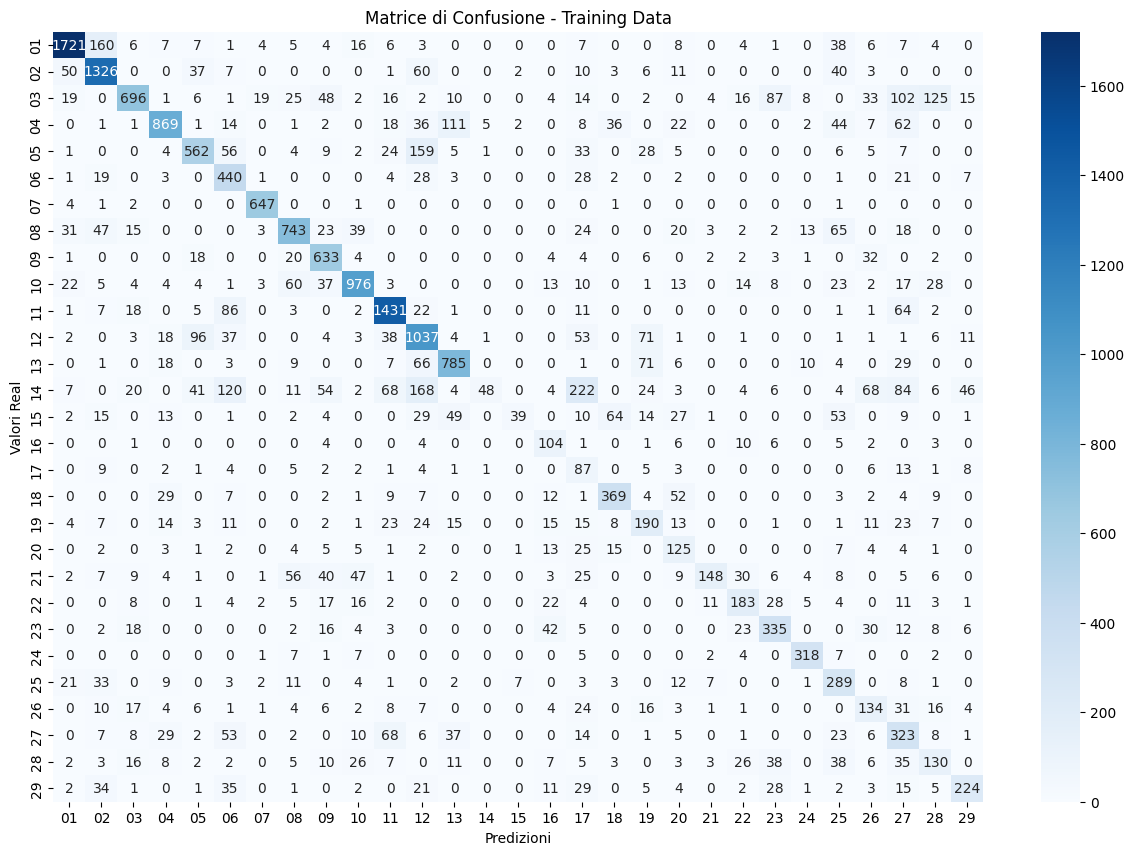

In [77]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Previsioni sui dati di addestramento
y_train_pred = pipeline.predict(X)

# Calcolare l'F1-score sui dati di addestramento
f1 = f1_score(y, y_train_pred, average='macro')
print(f"F1-score sui dati di addestramento: {f1:.2f}")

# Stampa il classification report
print("Classification Report sui dati di addestramento:")
print(classification_report(y, y_train_pred))

# Calcolare la matrice di confusione
conf_matrix = confusion_matrix(y, y_train_pred)

# Visualizzare la matrice di confusione
plt.figure(figsize=(15, 10))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=y.unique(), yticklabels=y.unique())
plt.title("Matrice di Confusione - Training Data")
plt.xlabel("Predizioni")
plt.ylabel("Valori Real")
plt.show()


PREPARAZIONE DATI DI TEST PER VALUTAZIONE FINALE

In [17]:
#ho aggiunto lable 
for trace in datasetTracesTestFeatExtr:
    trace['TraceDataFeatExtr']['timestamp'] = [1 + i * 0.5 for i in range(len(trace['TraceDataFeatExtr']))]
    trace['TraceDataFeatExtr']['target']=trace['TraceIDFeatExtr'].split('_')[3] #creo una nuova colonna target a cui associo il valore di activity che sta nel traceid

    # Aggiorno la colonna 'target' per gestire l'attività '7' -> '07'
    trace['TraceDataFeatExtr']['target'] = trace['TraceDataFeatExtr']['target'].replace('7', '07')
    
print(datasetTracesTestFeatExtr[0]["TraceDataFeatExtr"])

#concatenato tutti i vari Dataframe =>ottengo un'unica grande matrice
input_matrix_test = pd.concat([item['TraceDataFeatExtr'] for item in datasetTracesTestFeatExtr], ignore_index=True)
print("dimensioni input_matrix:", input_matrix_test.shape)
print(input_matrix_test.head(10))

     Ax_Absolute energy  Ax_Area under the curve  Ax_Autocorrelation  \
0             42.829785                 0.553478                 5.0   
1             46.434435                 0.583947                 5.0   
2             48.189979                 0.595957                 5.0   
3             34.103409                 0.512215                 5.0   
4             23.476067                 0.446081                 2.0   
..                  ...                      ...                 ...   
128           84.357713                 0.898139                 3.0   
129           89.795962                 0.914995                 5.0   
130           97.793906                 0.954214                 4.0   
131           99.826795                 0.977357                 3.0   
132          102.317720                 0.989128                 3.0   

     Ax_Average power  Ax_Centroid  Ax_ECDF Percentile Count_0  \
0           43.262409     0.480037                        20.0   
1  

SALVATAGGIO INPUT MATRIX TEST

In [18]:
# Salva la matrice in un file CSV
input_matrix_test.to_csv('input_matrix_test.csv', index=False)

DATI DI TEST, CONFUSION MATRIX E REPORT DI CLASSIFICAZIONE

Pipeline caricata con successo.
Classi uniche in y_test: ['01', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29']
Numero di classi in y_test: 28
F1-score sui dati di test: 0.42
Classification Report sui dati di test:


c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

              precision    recall  f1-score   support

          01       0.93      0.79      0.86       547
          02       0.00      0.00      0.00         0
          03       0.69      0.36      0.47       230
          04       0.69      0.69      0.69       255
          05       0.71      0.33      0.45       287
          06       0.39      0.42      0.41       141
          07       0.68      0.94      0.79       170
          08       0.60      0.28      0.38       213
          09       0.59      0.87      0.70       167
          10       0.59      0.58      0.59       231
          11       0.60      0.96      0.74       421
          12       0.57      0.56      0.56       399
          13       0.60      0.50      0.55       227
          14       0.00      0.00      0.00       331
          15       0.57      0.06      0.11        69
          16       0.39      0.76      0.51        29
          17       0.09      0.64      0.16        28
          18       0.72    

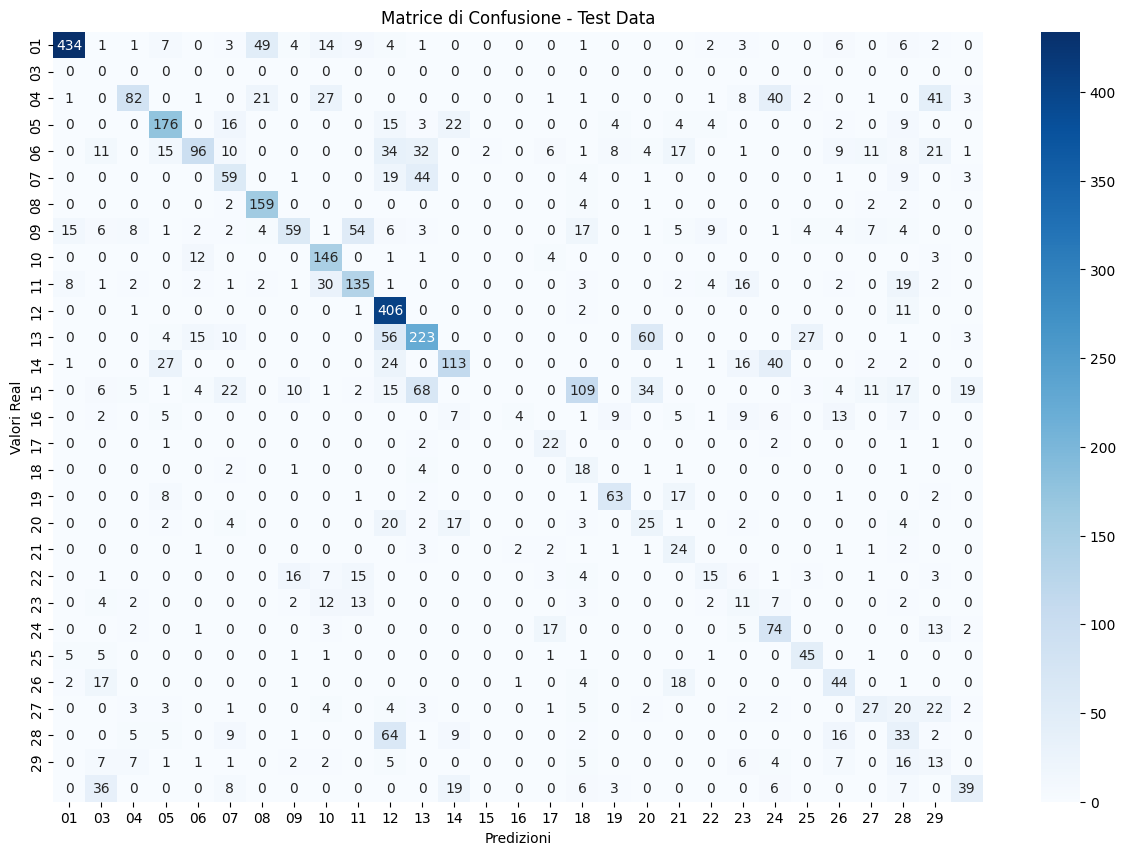

In [78]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pickle

# Caricamento pipeline salvata
with open("final_rf_pipeline.pkl", "rb") as f:
    pipeline = pickle.load(f)
print("Pipeline caricata con successo.")

# Preparazione dei dati di test
y_test = input_matrix_test["target"]
X_test = input_matrix_test.drop(columns=["target", "timestamp"])  # Rimuovi colonne non necessarie
print("Classi uniche in y_test:", sorted(y_test.unique()))
print("Numero di classi in y_test:", len(y_test.unique()))



# uso del miglior modello per fare previsioni sui dati 
y_pred = pipeline.predict(X_test) #y_pred= array che contiene le etichette previste dal modello per ciascun esempio in X


# Calcolare l'F1-score sui dati di addestramento
f1 = f1_score(y_test, y_pred, average='macro')
print(f"F1-score sui dati di test: {f1:.2f}")

# Stampa il classification report
print("Classification Report sui dati di test:")
print(classification_report(y_test, y_pred))

# Calcolare la matrice di confusione
cm = confusion_matrix(y_test, y_pred)

# Visualizzare la matrice di confusione
plt.figure(figsize=(15, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=y_test.unique(), yticklabels=y_test.unique())
plt.title("Matrice di Confusione - Test Data")
plt.xlabel("Predizioni")
plt.ylabel("Valori Real")
plt.show()








c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

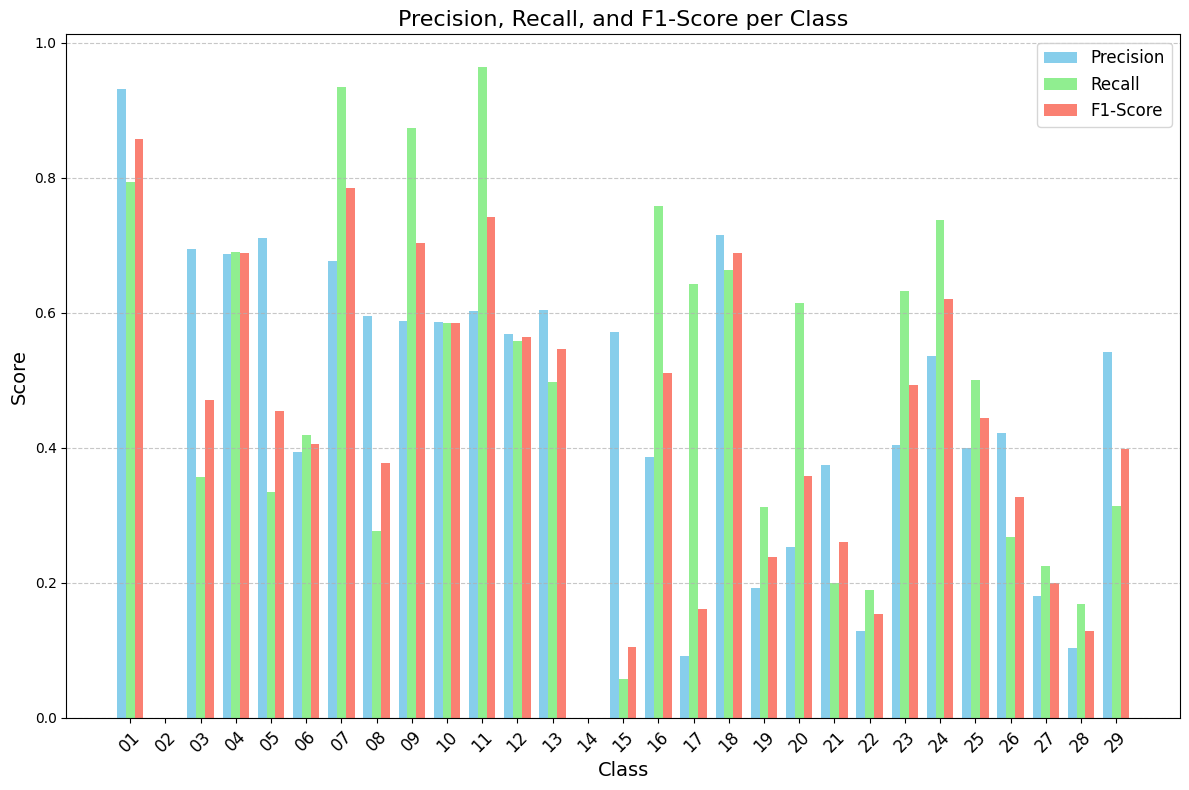

In [75]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

#report di classificazione
report_dict = classification_report(y_test, y_pred, output_dict=True)

#  precision, recall, F1-score per ciascuna classe
class_names = list(report_dict.keys())[:-3]  
precision = [report_dict[c]['precision'] for c in class_names]
recall = [report_dict[c]['recall'] for c in class_names]
f1_score = [report_dict[c]['f1-score'] for c in class_names]

# Creazione dei grafici a barre per Precision, Recall, e F1-score
x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(12, 8))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1_score, width, label='F1-Score', color='salmon')

plt.xticks(x, class_names, rotation=45, fontsize=12)
plt.title('Precision, Recall, and F1-Score per Class', fontsize=16)
plt.xlabel('Class', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
